In [190]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
import os
from medmnist import INFO, OrganAMNIST

In [191]:
import torchvision.transforms as transforms
selected_transform = transforms.ToTensor()
dataset_name = 'OrganAMNIST'  # 'CIFAR10' or 'MNIST' or 'OrganAMNIST'

In [192]:
if dataset_name == 'MNIST':
    data_dir = '../data/MNIST/'
    print(data_dir)
    train_set = datasets.MNIST(data_dir, train=True, download=True, transform=selected_transform)
    test_set = datasets.MNIST(data_dir, train=False, download=True, transform=selected_transform)

elif dataset_name == 'CIFAR10':
    data_dir = '../data/CIFAR10/'
    print(data_dir)
    train_set = datasets.CIFAR10(data_dir, train=True, download=True, transform=selected_transform)
    test_set = datasets.CIFAR10(data_dir, train=False, download=True, transform=selected_transform)

elif dataset_name == 'OrganAMNIST':
    data_dir = '../data/OrganAMNIST/'
    os.makedirs(data_dir, exist_ok=True)
    print(data_dir)
    train_set = OrganAMNIST(root=data_dir, split='train', download=True, transform=selected_transform)
    test_set = OrganAMNIST(root=data_dir, split='test', download=True, transform=selected_transform)

else:
    raise ValueError("Invalid dataset name.")

../data/OrganAMNIST/
Using downloaded and verified file: ../data/OrganAMNIST/organamnist.npz
Using downloaded and verified file: ../data/OrganAMNIST/organamnist.npz


In [193]:
if dataset_name == 'MNIST':
    def filtered_dataset(train_set, test_set, filtered=0, dataset_name=None):
        if filtered == 0:  # Classes 0 and 1 only
            if(True):
                try:
                    train_indexes_0 = torch.where(train_set.targets == 0)[0]
                    train_indexes_1 = torch.where(train_set.targets == 1)[0]
                    test_indexes_0 = torch.where(test_set.targets == 0)[0]
                    test_indexes_1 = torch.where(test_set.targets == 1)[0]
                except AttributeError:
                    train_indexes_0 = torch.where(torch.tensor(train_set.labels) == 0)[0]
                    train_indexes_1 = torch.where(torch.tensor(train_set.labels) == 1)[0]
                    test_indexes_0 = torch.where(torch.tensor(test_set.labels) == 0)[0]
                    test_indexes_1 = torch.where(torch.tensor(test_set.labels) == 1)[0]

            num_to_sample_train = min(len(train_indexes_0), len(train_indexes_1))
            num_to_sample_test = min(len(test_indexes_0), len(test_indexes_1))

            sampled_train_indexes_0 = train_indexes_0[torch.randperm(len(train_indexes_0))[:num_to_sample_train]]
            sampled_train_indexes_1 = train_indexes_1[torch.randperm(len(train_indexes_1))[:num_to_sample_train]]
            sampled_test_indexes_0 = test_indexes_0[torch.randperm(len(test_indexes_0))[:num_to_sample_test]]
            sampled_test_indexes_1 = test_indexes_1[torch.randperm(len(test_indexes_1))[:num_to_sample_test]]

            selected_train_indexes = torch.cat([sampled_train_indexes_0, sampled_train_indexes_1])
            selected_test_indexes = torch.cat([sampled_test_indexes_0, sampled_test_indexes_1])

        elif filtered == 1:  # All 10 classes
            train_indexes = []
            test_indexes = []
            for i in range(10):
                if(True):
                    try:
                        train_idx = torch.where(train_set.targets == i)[0]
                        test_idx = torch.where(test_set.targets == i)[0]
                    except AttributeError:
                        train_idx = torch.where(torch.tensor(train_set.labels) == i)[0]
                        test_idx = torch.where(torch.tensor(test_set.labels) == i)[0]

                train_indexes.append(train_idx)
                test_indexes.append(test_idx)

            min_num_samples_train = min(len(idx) for idx in train_indexes)
            min_num_samples_test = min(len(idx) for idx in test_indexes)

            sampled_train_indexes = []
            sampled_test_indexes = []
            for train_idx, test_idx in zip(train_indexes, test_indexes):
                sampled_train_indexes.append(train_idx[torch.randperm(len(train_idx))[:min_num_samples_train]])
                sampled_test_indexes.append(test_idx[torch.randperm(len(test_idx))[:min_num_samples_test]])

            selected_train_indexes = torch.cat(sampled_train_indexes)
            selected_test_indexes = torch.cat(sampled_test_indexes)

        else:
            raise ValueError("Invalid value for 'filtered'. Choose either 0 or 1.")

        filtered_train_set = torch.utils.data.Subset(train_set, selected_train_indexes)
        filtered_test_set = torch.utils.data.Subset(test_set, selected_test_indexes)

        return filtered_train_set, filtered_test_set

elif dataset_name == 'CIFAR10':
    def filtered_dataset(train_set, test_set, filtered=0, dataset_name=None):
        # CIFAR-10 classes:
        # 0: airplane, 1: automobile, 2: bird, 3: cat, 4: deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck

        # Convert targets to tensors if they are lists
        train_targets_tensor = torch.tensor(train_set.targets)
        test_targets_tensor = torch.tensor(test_set.targets)

        if filtered == 0:  # Classes 0 and 1 only
            train_indexes_0 = torch.where(train_targets_tensor == 0)[0]
            train_indexes_1 = torch.where(train_targets_tensor == 1)[0]
            test_indexes_0 = torch.where(test_targets_tensor == 0)[0]
            test_indexes_1 = torch.where(test_targets_tensor == 1)[0]

            num_to_sample_train = min(len(train_indexes_0), len(train_indexes_1))
            num_to_sample_test = min(len(test_indexes_0), len(test_indexes_1))

            sampled_train_indexes_0 = train_indexes_0[torch.randperm(len(train_indexes_0))[:num_to_sample_train]]
            sampled_train_indexes_1 = train_indexes_1[torch.randperm(len(train_indexes_1))[:num_to_sample_train]]
            sampled_test_indexes_0 = test_indexes_0[torch.randperm(len(test_indexes_0))[:num_to_sample_test]]
            sampled_test_indexes_1 = test_indexes_1[torch.randperm(len(test_indexes_1))[:num_to_sample_test]]

            selected_train_indexes = torch.cat([sampled_train_indexes_0, sampled_train_indexes_1])
            selected_test_indexes = torch.cat([sampled_test_indexes_0, sampled_test_indexes_1])

        elif filtered == 1:  # All 10 classes
            train_indexes = []
            test_indexes = []
            for i in range(10):
                train_idx = torch.where(train_targets_tensor == i)[0]
                test_idx = torch.where(test_targets_tensor == i)[0]

                train_indexes.append(train_idx)
                test_indexes.append(test_idx)

            min_num_samples_train = min(len(idx) for idx in train_indexes)
            min_num_samples_test = min(len(idx) for idx in test_indexes)

            sampled_train_indexes = []
            sampled_test_indexes = []
            for train_idx, test_idx in zip(train_indexes, test_indexes):
                sampled_train_indexes.append(train_idx[torch.randperm(len(train_idx))[:min_num_samples_train]])
                sampled_test_indexes.append(test_idx[torch.randperm(len(test_idx))[:min_num_samples_test]])

            selected_train_indexes = torch.cat(sampled_train_indexes)
            selected_test_indexes = torch.cat(sampled_test_indexes)

        else:
            raise ValueError("Invalid value for 'filtered'. Choose either 0 or 1.")

        filtered_train_set = torch.utils.data.Subset(train_set, selected_train_indexes)
        filtered_test_set = torch.utils.data.Subset(test_set, selected_test_indexes)

        return filtered_train_set, filtered_test_set

elif dataset_name == 'OrganAMNIST':
    def filtered_dataset(train_set, test_set, filtered=0, dataset_name=None):
        # OrganAMNIST classes:
        # 0: bladder, 1: femur-left, 2: femur-right, 3: heart, 4: kidney-left, 5: kidney-right, 6: liver, 7: lung-left, 8: lung-right, 9: pancreas, 10: spleen

        train_targets_tensor = torch.tensor(train_set.labels)
        test_targets_tensor = torch.tensor(test_set.labels)

        if filtered == 0:  # Classes 0 and 1 only
            train_indexes_0 = torch.where(train_targets_tensor == 0)[0]
            train_indexes_1 = torch.where(train_targets_tensor == 1)[0]
            test_indexes_0 = torch.where(test_targets_tensor == 0)[0]
            test_indexes_1 = torch.where(test_targets_tensor == 1)[0]

            num_to_sample_train = min(len(train_indexes_0), len(train_indexes_1))
            num_to_sample_test = min(len(test_indexes_0), len(test_indexes_1))

            sampled_train_indexes_0 = train_indexes_0[torch.randperm(len(train_indexes_0))[:num_to_sample_train]]
            sampled_train_indexes_1 = train_indexes_1[torch.randperm(len(train_indexes_1))[:num_to_sample_train]]
            sampled_test_indexes_0 = test_indexes_0[torch.randperm(len(test_indexes_0))[:num_to_sample_test]]
            sampled_test_indexes_1 = test_indexes_1[torch.randperm(len(test_indexes_1))[:num_to_sample_test]]

            selected_train_indexes = torch.cat([sampled_train_indexes_0, sampled_train_indexes_1])
            selected_test_indexes = torch.cat([sampled_test_indexes_0, sampled_test_indexes_1])

        elif filtered == 1:  # All 11 classes
            train_indexes = []
            test_indexes = []
            for i in range(11):
                train_idx = torch.where(train_targets_tensor == i)[0]
                test_idx = torch.where(test_targets_tensor == i)[0]
                train_indexes.append(train_idx)
                test_indexes.append(test_idx)

            min_num_samples_train = min(len(idx) for idx in train_indexes)
            min_num_samples_test = min(len(idx) for idx in test_indexes)

            sampled_train_indexes = []
            sampled_test_indexes = []
            for train_idx, test_idx in zip(train_indexes, test_indexes):
                sampled_train_indexes.append(train_idx[torch.randperm(len(train_idx))[:min_num_samples_train]])
                sampled_test_indexes.append(test_idx[torch.randperm(len(test_idx))[:min_num_samples_test]])

            selected_train_indexes = torch.cat(sampled_train_indexes)
            selected_test_indexes = torch.cat(sampled_test_indexes)
        else:
            raise ValueError("Invalid value for 'filtered'. Choose either 0 or 1.")

        filtered_train_set = torch.utils.data.Subset(train_set, selected_train_indexes)
        filtered_test_set = torch.utils.data.Subset(test_set, selected_test_indexes)
        return filtered_train_set, filtered_test_set

else:
    raise ValueError("Invalid dataset name.")

In [194]:
global filtered_train_set, filtered_test_set
global filtered_train_loader, filtered_test_loader

print("Dataset:", dataset_name)

filtered_train_set, filtered_test_set = filtered_dataset(train_set, test_set, filtered=1)

# Select 100% of samples
def subset_dataset(dataset, fraction=1, seed=42):
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), int(len(dataset) * fraction), replace=False)
    return Subset(dataset, indices)

filtered_train_set = subset_dataset(filtered_train_set, fraction=1)
filtered_test_set = subset_dataset(filtered_test_set, fraction=1)

filtered_train_loader = DataLoader(filtered_train_set, batch_size=128, shuffle=True)
filtered_test_loader = DataLoader(filtered_test_set, batch_size=128)

# Print the exact number of images in the filtered sets
print("Number of images in the filtered training set:", len(filtered_train_set))
print("Number of images in the filtered test set:", len(filtered_test_set))

# Print the number of batches in the data loaders
print("Number of batches in the filtered training set:", len(filtered_train_loader))
print("Number of batches in the filtered test set:", len(filtered_test_loader))

Dataset: OrganAMNIST
Number of images in the filtered training set: 14927
Number of images in the filtered test set: 8624
Number of batches in the filtered training set: 117
Number of batches in the filtered test set: 68


In [195]:
if dataset_name == 'MNIST':
    def print_images(images, labels):
        n_classes = 10
        fig = plt.figure(figsize=(2 * n_classes, 2))
        shown = set()
        for i in range(len(labels)):
            label = labels[i].item()
            if label not in shown:
                ax = fig.add_subplot(1, n_classes, label + 1)
                img = images[i].squeeze()
                ax.imshow(img, cmap='gray')
                ax.set_title(f"{label}", color='blue')
                ax.axis('off')
                shown.add(label)
                if len(shown) == n_classes:
                    break
        plt.savefig("[Dataset] MNIST.pdf", bbox_inches="tight", pad_inches=0.1)
        plt.show()

elif dataset_name == 'CIFAR10':
    def print_images(imgs, labels):
        cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
        n_classes = 10
        shown = set()
        imgs = imgs.permute(0, 2, 3, 1).cpu().numpy()
        imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())
        fig, axes = plt.subplots(1, n_classes, figsize=(2 * n_classes, 2))
        idx = 0
        for i in range(len(labels)):
            label = labels[i].item()
            if label not in shown:
                axes[idx].imshow(imgs[i])
                axes[idx].set_title(f"{cifar10_classes[label]}", color='blue')
                axes[idx].axis('off')
                shown.add(label)
                idx += 1
                if len(shown) == n_classes:
                    break
        plt.savefig("[Dataset] CIFAR10.pdf", bbox_inches="tight", pad_inches=0.1)
        plt.show()

elif dataset_name == 'OrganAMNIST':
    def print_images(imgs, labels):
        organamnist_classes = [v for k, v in INFO['organamnist']['label'].items()]
        n_classes = len(organamnist_classes)
        shown = set()
        imgs = imgs.permute(0, 2, 3, 1).cpu().numpy()
        imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())
        fig, axes = plt.subplots(1, n_classes, figsize=(2 * n_classes, 2))
        idx = 0
        for i in range(len(labels)):
            label = labels[i].item()
            if label not in shown:
                axes[idx].imshow(imgs[i].squeeze(), cmap='gray')
                axes[idx].set_title(f"{organamnist_classes[label]}", color='blue')
                axes[idx].axis('off')
                shown.add(label)
                idx += 1
                if len(shown) == n_classes:
                    break
        plt.savefig("[Dataset] OrganAMNIST.pdf", bbox_inches="tight", pad_inches=0.1)
        plt.show()

else:
    raise ValueError("Invalid dataset name.")


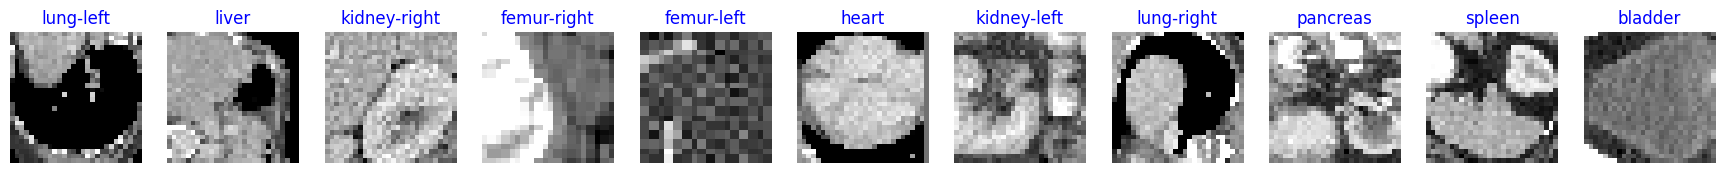

In [196]:
# Get a batch of images and labels
images, labels = next(iter(filtered_train_loader))

# Show one image per class with class name in blue
print_images(images, labels)